# MODULE 5 — FBGAN Data Augmentation
**Requires:** `eeg_data_bundle.pkl` from Module 1

**Goal:** Train FBGAN on target-subject calibration data (session 0), generate
synthetic EEG, verify quality, then compare CRNN-DF with vs without augmentation.

✅ **Pass criterion:** Augmented accuracy ≥ non-augmented − 2%  (GAN not hurting)

> **Runtime:** ~25–40 min on Apple M-series (150 epochs × 4 classes)

In [1]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import pickle, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
IS_MPS = (device.type == 'mps')
print(f'Device: {device}')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

with open('eeg_data_bundle.pkl', 'rb') as f:
    d = pickle.load(f)
X_raw    = d['X_raw'];    y_enc    = d['y_enc']
subjects = d['subjects']; sessions = d['sessions']
S0=d['S0']; S1=d['S1'];   CLASSES  = d['classes']
FS = d['FS']
print(f'Data loaded.  X:{X_raw.shape}  S0={S0!r}(calib)  S1={S1!r}(test)')


Device: mps
Data loaded.  X:(5184, 22, 1000)  S0='0train'(calib)  S1='1test'(test)


In [2]:
# ─── Preprocessing ────────────────────────────────────────────────────────
def zscore(X_tr, X_other):
    mu  = X_tr.mean(axis=(0,2), keepdims=True)
    std = X_tr.std (axis=(0,2), keepdims=True) + 1e-8
    return (X_tr - mu) / std, (X_other - mu) / std

def make_loader(X, y, bs=32, shuffle=True):
    return DataLoader(
        TensorDataset(torch.FloatTensor(X), torch.LongTensor(y)),
        batch_size=bs, shuffle=shuffle, drop_last=True)

def predict(model, X, bs=64):
    model.eval(); preds = []
    Xt = torch.FloatTensor(X)
    with torch.no_grad():
        for i in range(0, len(Xt), bs):
            l, _ = model(Xt[i:i+bs].to(device))
            preds.extend(l.argmax(1).cpu().numpy())
    return np.array(preds)

# ─── CRNN ─────────────────────────────────────────────────────────────────
class CRNN(nn.Module):
    def __init__(self, n_ch=22, n_t=1000, n_cls=4, hidden=64, dropout=0.5):
        super().__init__()
        self.feature_dim  = hidden
        self.spatial_conv = nn.Conv2d(1, 32, kernel_size=(n_ch, 45), padding=0)
        self.bn           = nn.BatchNorm2d(32)
        self.relu         = nn.ReLU(inplace=True)
        self.drop_cnn     = nn.Dropout(dropout)
        self.pool         = nn.MaxPool2d((1, 75), stride=(1, 10))
        lstm_drop = 0.0 if IS_MPS else dropout
        self.lstm         = nn.LSTM(32, hidden, num_layers=2,
                                    batch_first=True, dropout=lstm_drop)
        self.drop_lstm    = nn.Dropout(dropout)
        self.classifier   = nn.Linear(hidden, n_cls)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.drop_cnn(self.relu(self.bn(self.spatial_conv(x))))
        x = self.pool(x)
        x = x.squeeze(2).permute(0, 2, 1)
        _, (h, _) = self.lstm(x)
        feat = self.drop_lstm(h[-1])
        return self.classifier(feat), feat

# ─── CenterLoss (EMA, no SGD on centers) ─────────────────────────────────
class CenterLoss(nn.Module):
    def __init__(self, n_cls=4, feat_dim=64, lr_c=0.5):
        super().__init__()
        self.n_cls = n_cls; self.lr_c = lr_c
        self.register_buffer('centers', torch.zeros(n_cls, feat_dim))

    @torch.no_grad()
    def init_from_data(self, model, X, y, bs=64):
        model.eval()
        all_f, all_l = [], []
        Xt = torch.FloatTensor(X); yt = torch.LongTensor(y)
        for i in range(0, len(Xt), bs):
            _, f = model(Xt[i:i+bs].to(device))
            all_f.append(f.detach().cpu()); all_l.append(yt[i:i+bs])
        F = torch.cat(all_f); L = torch.cat(all_l)
        for c in range(self.n_cls):
            m = (L == c)
            if m.sum() > 0:
                self.centers[c] = F[m].mean(0).to(self.centers.device)
        model.train()

    @torch.no_grad()
    def update_centers(self, feats, labels):
        feats = feats.detach(); labels = labels.detach()
        for c in range(self.n_cls):
            mask = (labels == c)
            if mask.sum() == 0: continue
            diff = self.centers[c] - feats[mask].mean(0)
            self.centers[c] -= self.lr_c * diff / (mask.sum().float() + 1)

    @torch.no_grad()
    def expand_inter_class(self, alpha=0.02):
        gc = self.centers.mean(0, keepdim=True)
        d  = self.centers - gc
        self.centers.add_(alpha * d / (d.norm(dim=1, keepdim=True) + 1e-8))

    def forward(self, feats, labels):
        c = self.centers[labels].detach()
        return torch.mean(torch.norm(feats - c, dim=1))

# ─── CRNN-DF trainer ──────────────────────────────────────────────────────
def train_crnn_df(X_tr, y_tr, n_epochs=150, lam=0.1, warmup=30, verbose=True):
    model = CRNN().to(device)
    closs = CenterLoss().to(device)
    opt   = optim.Adam(model.parameters(), lr=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=1e-6)
    ce    = nn.CrossEntropyLoss()
    loader= make_loader(X_tr, y_tr)

    for ep in range(1, n_epochs + 1):
        if ep == warmup + 1:
            closs.init_from_data(model, X_tr, y_tr)
            if verbose: print(f'  [ep {ep}] Centers initialised')
        use_c = (ep > warmup)
        model.train()
        cor, tot_n = 0, 0
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, feats = model(Xb)
            loss = ce(logits, yb)
            if use_c:
                loss = loss + lam * closs(feats, yb)
                closs.update_centers(feats, yb)
            loss.backward(); opt.step()
            cor   += (logits.argmax(1) == yb).sum().item()
            tot_n += yb.size(0)
        sched.step()
        if use_c and ep % 15 == 0:
            closs.expand_inter_class()
        if verbose and ep % 50 == 0:
            phase = 'center' if use_c else 'warmup'
            print(f'  ep {ep:3d} [{phase}]  train={100*cor/tot_n:.1f}%')
    return model

print('CRNN / CenterLoss / train_crnn_df defined. ✅')


CRNN / CenterLoss / train_crnn_df defined. ✅


In [3]:
# ─── Generator Gθ (paper Table 1) ────────────────────────────────────────
class Generator(nn.Module):
    def __init__(self, noise_dim=1600, n_ch=22, n_t=1000):
        super().__init__()
        self.n_ch = n_ch; self.n_t = n_t
        self.fc  = nn.Linear(noise_dim, 128 * 4 * 4)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128, 128, (3,15), (1,3), (1,6)), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.ConvTranspose2d(128, 128, (3,15), (1,3), (1,6)), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.ConvTranspose2d(128,  64, (3, 5), (1,2), (1,2)), nn.BatchNorm2d(64),  nn.LeakyReLU(0.2, True),
            nn.ConvTranspose2d( 64,  32, (4, 5), (2,1), (1,2)), nn.BatchNorm2d(32),  nn.LeakyReLU(0.2, True),
            nn.ConvTranspose2d( 32,   1, (1, 2), (1,1), (0,0)), nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z).view(-1, 128, 4, 4)
        x = self.net(x)
        # Bilinear resize to exact target shape — robust to ConvTranspose off-by-ones
        return nn.functional.interpolate(
            x, size=(self.n_ch, self.n_t), mode='bilinear', align_corners=False)


# ─── Discriminator Dφ — operates on raw EEG (paper Table 2 top) ──────────
class DiscriminatorPhi(nn.Module):
    def __init__(self, n_ch=22, n_t=1000):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, True)
        self.c1  = nn.Conv2d( 1, 10, (1, 23), (1,1), (0,11))
        self.c2  = nn.Conv2d(10, 30, (n_ch, 1))
        self.c3  = nn.Conv2d(30, 30, (1, 17), (1,1), (0,8))
        self.p1  = nn.MaxPool2d((1, 6), (1, 6))
        self.c4  = nn.Conv2d(30, 30, (1, 7),  (1,7))
        self.p2  = nn.MaxPool2d((1, 6), (1, 6))
        # Compute output time-dim
        t = n_t
        for k, s, p in [(23,1,11), (17,1,8), (6,6,0), (7,7,0), (6,6,0)]:
            t = max(1, (t + 2*p - k) // s + 1)
        self.flat = 30 * max(t, 1)
        self.fc   = nn.Linear(self.flat, 1)

    def forward(self, x):                   # x: (B,1,C,T)
        x = self.act(self.c1(x))
        x = self.act(self.c2(x))
        x = self.act(self.c3(x))
        x = self.p1(x)
        x = self.act(self.c4(x))
        x = self.p2(x)
        x = x.reshape(x.size(0), -1)
        if x.shape[1] != self.flat:          # guard off-by-one
            buf = x.new_zeros(x.size(0), self.flat)
            mn  = min(x.shape[1], self.flat)
            buf[:, :mn] = x[:, :mn]; x = buf
        return torch.sigmoid(self.fc(x))


# ─── Discriminator Dψ — operates on sparse-filtered EEG (Table 2 bottom) ─
# Uses global avg-pool instead of AdaptiveAvgPool → MPS-compatible
class DiscriminatorPsi(nn.Module):
    def __init__(self, n_sparse=20):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, True)
        k1 = min(23, max(3, n_sparse)); p1 = k1 // 2
        self.c1 = nn.Conv2d( 1, 10, (1, k1), (1,1), (0, p1))
        self.c2 = nn.Conv2d(10, 30, (4,  1), (4,1))
        self.c3 = nn.Conv2d(30, 30, (1,  1))
        self.c4 = nn.Conv2d(30, 30, (1, 17), (1,1), (0, 8))
        self.p1 = nn.MaxPool2d((1, 6), (1, 6))
        self.c5 = nn.Conv2d(30, 30, (1,  7))
        self.p2 = nn.MaxPool2d((1, 6), (1, 6))
        self.fc = nn.Linear(30, 1)

    def forward(self, x):
        x = self.act(self.c1(x))
        x = self.act(self.c2(x))
        x = self.act(self.c3(x))
        x = self.act(self.c4(x))
        if x.shape[3] >= 6: x = self.p1(x)
        if x.shape[3] >= 7: x = self.act(self.c5(x))
        if x.shape[3] >= 6: x = self.p2(x)
        x = x.mean(dim=[2, 3])   # global avg pool — always safe
        return torch.sigmoid(self.fc(x))


# ─── Shape check ──────────────────────────────────────────────────────────
_G  = Generator(1600, 22, 1000).to(device)
_Dp = DiscriminatorPhi(22, 1000).to(device)
_Ds = DiscriminatorPsi(20).to(device)
_z  = torch.randn(2, 1600, device=device)
_f  = _G(_z)
assert _f.shape == (2, 1, 22, 1000), f'Bad G shape: {_f.shape}'
assert _Dp(_f).shape == (2, 1)
assert _Ds(_f[:, :, :, :20]).shape == (2, 1)
del _G, _Dp, _Ds, _z, _f
print('FBGAN architecture defined + shape check passed. ✅')


FBGAN architecture defined + shape check passed. ✅


In [4]:
def train_fbgan_one_class(X_cls, n_ch, n_t, n_sparse,
                          noise_dim=1600, n_epochs=150,
                          batch_size=8, n_fake=750):
    """
    Train FBGAN for one MI class on target-subject calibration data.
    Returns fake EEG (n_fake, n_ch, n_t) and loss history.
    """
    # Ensure enough samples for one batch
    if len(X_cls) < batch_size:
        reps  = int(np.ceil(batch_size / max(len(X_cls), 1)))
        X_cls = np.tile(X_cls, (reps, 1, 1))[:batch_size]

    loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_cls[:, np.newaxis])),
        batch_size=batch_size, shuffle=True, drop_last=True)

    G     = Generator(noise_dim, n_ch, n_t).to(device)
    D_phi = DiscriminatorPhi(n_ch, n_t).to(device)
    D_psi = DiscriminatorPsi(n_sparse).to(device)

    opt_G = optim.Adam(G.parameters(),     lr=1e-4, betas=(0.5, 0.999))
    opt_D = optim.Adam(
        list(D_phi.parameters()) + list(D_psi.parameters()),
        lr=1e-4, betas=(0.5, 0.999))
    bce   = nn.BCELoss()
    sl    = slice(0, min(n_sparse, n_t))   # sparse-filter slice

    g_hist, d_hist = [], []

    for ep in range(n_epochs):
        ep_g, ep_d = 0.0, 0.0
        for (real,) in loader:
            real = real.to(device); bs = real.size(0)
            ones  = torch.ones (bs, 1, device=device)
            zeros = torch.zeros(bs, 1, device=device)

            # ── Discriminator step ─────────────────────────────────────
            opt_D.zero_grad()
            with torch.no_grad():
                fake = G(torch.randn(bs, noise_dim, device=device))
            Ld = (bce(D_phi(real),              ones)  +
                  bce(D_phi(fake),              zeros) +
                  bce(D_psi(real[:,:,:,sl]),    ones)  +
                  bce(D_psi(fake[:,:,:,sl]),    zeros))
            Ld.backward(); opt_D.step()

            # ── Generator step ─────────────────────────────────────────
            opt_G.zero_grad()
            fake = G(torch.randn(bs, noise_dim, device=device))
            Lg   = (bce(D_phi(fake),           ones) +
                    bce(D_psi(fake[:,:,:,sl]), ones))
            Lg.backward(); opt_G.step()

            ep_g += Lg.item(); ep_d += Ld.item()

        g_hist.append(ep_g / len(loader))
        d_hist.append(ep_d / len(loader))

    # ── Generate fake samples ──────────────────────────────────────────
    G.eval()
    chunks = []
    with torch.no_grad():
        for i in range(0, n_fake, 32):
            z = torch.randn(min(32, n_fake - i), noise_dim, device=device)
            chunks.append(G(z).squeeze(1).cpu().numpy())
    fakes = np.vstack(chunks)[:n_fake].astype(np.float32)
    return fakes, g_hist, d_hist


def train_fbgan_all_classes(X_calib, y_calib, n_sparse,
                             n_epochs=150, n_fake=750, n_cls=4):
    """Train FBGAN for all 4 classes. Returns (fake_X, fake_y, losses)."""
    n_ch, n_t    = X_calib.shape[1], X_calib.shape[2]
    all_fake_X   = []
    all_g, all_d = [], []

    for cls in range(n_cls):
        X_cls = X_calib[y_calib == cls]
        print(f'  Class {cls} ({CLASSES[cls]}): {len(X_cls)} real → {n_fake} fake ...')
        fakes, gl, dl = train_fbgan_one_class(
            X_cls, n_ch, n_t, n_sparse,
            n_epochs=n_epochs, n_fake=n_fake)
        all_fake_X.append(fakes)
        all_g.append(gl); all_d.append(dl)
        print(f'    Done  G={gl[-1]:.3f}  D={dl[-1]:.3f}')

    fake_X = np.vstack(all_fake_X).astype(np.float32)
    fake_y = np.repeat(np.arange(n_cls), n_fake).astype(np.int64)
    return fake_X, fake_y, all_g, all_d

print('FBGAN training functions defined. ✅')


FBGAN training functions defined. ✅


In [5]:
TEST_SUBJ = '1'
N_SPARSE  = 20     # approx filter count for Dψ input width
N_FAKE    = 750    # fake trials per class
GAN_EPOCHS= 150

m_tr  = subjects != TEST_SUBJ
m_cal = (subjects == TEST_SUBJ) & (sessions == S0)
m_te  = (subjects == TEST_SUBJ) & (sessions == S1)

X_tr_n,  X_te_n = zscore(X_raw[m_tr], X_raw[m_te])
_,       X_ca_n = zscore(X_raw[m_tr], X_raw[m_cal])
y_tr = y_enc[m_tr]; y_ca = y_enc[m_cal]; y_te = y_enc[m_te]

print(f'Calib: {X_ca_n.shape}  class dist: {np.bincount(y_ca)}')
print(f'Training FBGAN ({GAN_EPOCHS} epochs × 4 classes)...\n')

fake_X, fake_y, g_losses, d_losses = train_fbgan_all_classes(
    X_ca_n, y_ca, N_SPARSE, n_epochs=GAN_EPOCHS, n_fake=N_FAKE)

print(f'\nGenerated: {fake_X.shape}  labels: {np.bincount(fake_y)}')


Calib: (288, 22, 1000)  class dist: [72 72 72 72]
Training FBGAN (150 epochs × 4 classes)...

  Class 0 (feet): 72 real → 750 fake ...
    Done  G=11.630  D=0.063
  Class 1 (left_hand): 72 real → 750 fake ...
    Done  G=10.454  D=0.148
  Class 2 (right_hand): 72 real → 750 fake ...
    Done  G=10.755  D=0.132
  Class 3 (tongue): 72 real → 750 fake ...
    Done  G=11.938  D=0.084

Generated: (3000, 22, 1000)  labels: [750 750 750 750]


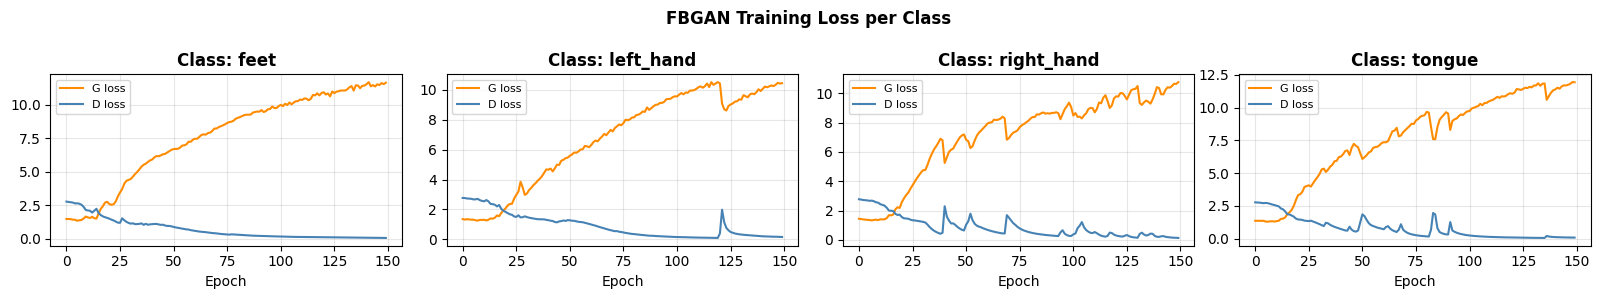

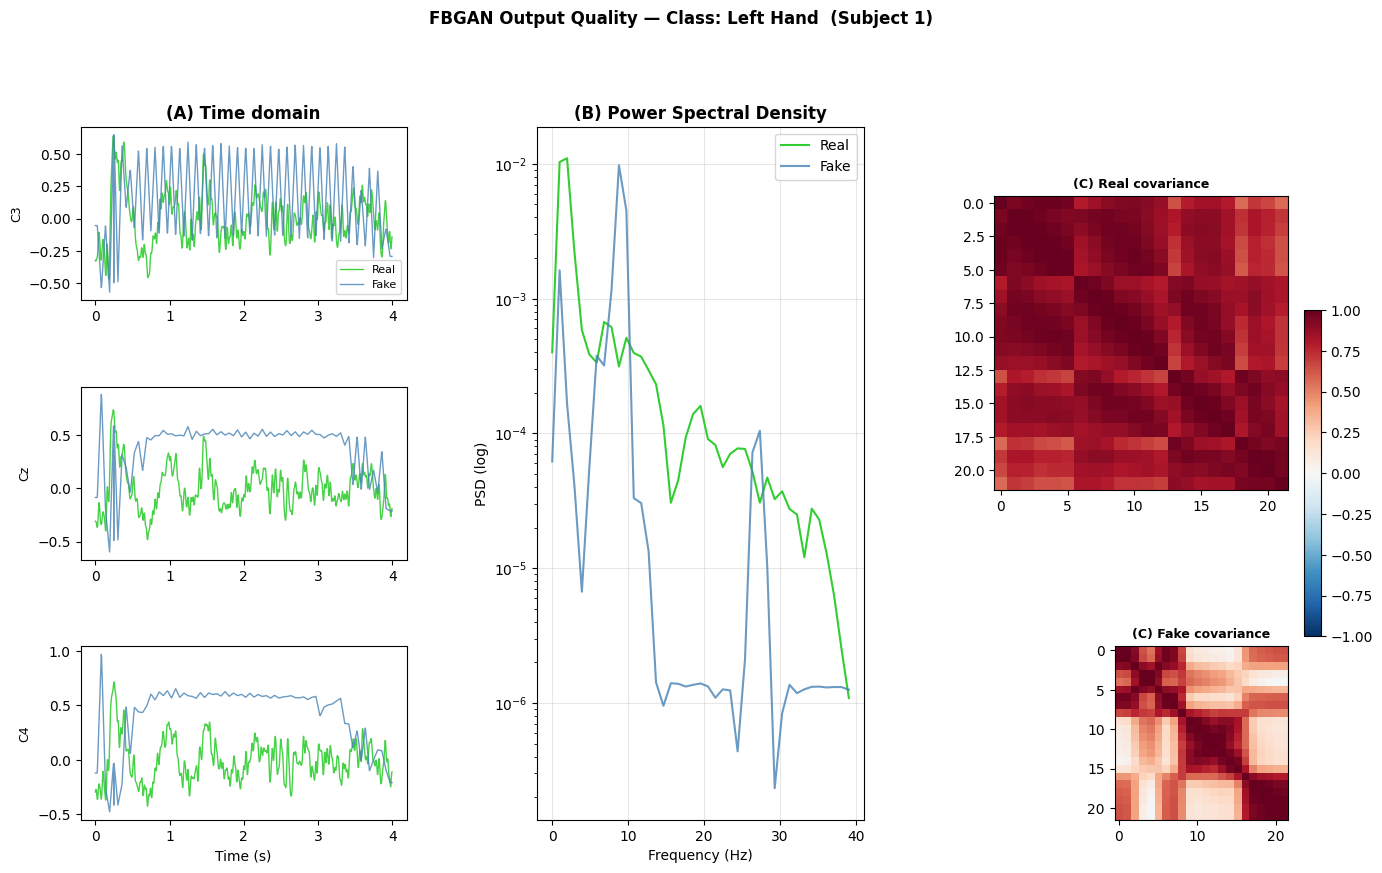

Quality plots saved.


In [6]:
# ─── 6a: GAN training loss curves ────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for cls in range(4):
    axes[cls].plot(g_losses[cls], color='darkorange', label='G loss')
    axes[cls].plot(d_losses[cls], color='steelblue',  label='D loss')
    axes[cls].set_title(f'Class: {CLASSES[cls]}', fontweight='bold')
    axes[cls].set_xlabel('Epoch'); axes[cls].legend(fontsize=8)
    axes[cls].grid(alpha=0.3)
plt.suptitle('FBGAN Training Loss per Class', fontweight='bold')
plt.tight_layout()
plt.savefig('m5_gan_losses.png', dpi=120, bbox_inches='tight')
plt.show()

# ─── 6b: Signal quality check (paper Fig. 7 style) ───────────────────────
real_cls = X_ca_n[y_ca == 0]         # left hand, real
fake_cls = fake_X[fake_y == 0]       # left hand, fake
real_avg = real_cls.mean(0)
fake_avg = fake_cls.mean(0)
time_ax  = np.arange(1000) / FS
MI_CHS   = [7, 9, 11]; CH_NAMES = ['C3', 'Cz', 'C4']

fig = plt.figure(figsize=(16, 9))
gs  = fig.add_gridspec(3, 3, hspace=0.5, wspace=0.4)

# (A) Time domain
for row, (ch, name) in enumerate(zip(MI_CHS, CH_NAMES)):
    ax = fig.add_subplot(gs[row, 0])
    ax.plot(time_ax, real_avg[ch], color='limegreen', lw=1.0, label='Real', alpha=0.9)
    ax.plot(time_ax, fake_avg[ch], color='steelblue', lw=1.0, label='Fake', alpha=0.8)
    ax.set_ylabel(name, fontsize=9)
    if row == 0: ax.set_title('(A) Time domain', fontweight='bold'); ax.legend(fontsize=8)
    if row == 2: ax.set_xlabel('Time (s)')

# (B) PSD
ax_psd = fig.add_subplot(gs[:, 1])
from scipy.signal import welch
f_r, p_r = welch(real_cls.mean(0).mean(0), fs=FS, nperseg=256)
f_f, p_f = welch(fake_cls.mean(0).mean(0), fs=FS, nperseg=256)
mask = f_r <= 40
ax_psd.semilogy(f_r[mask], p_r[mask], color='limegreen', lw=1.5, label='Real')
ax_psd.semilogy(f_f[mask], p_f[mask], color='steelblue', lw=1.5, label='Fake', alpha=0.8)
ax_psd.set_title('(B) Power Spectral Density', fontweight='bold')
ax_psd.set_xlabel('Frequency (Hz)'); ax_psd.set_ylabel('PSD (log)')
ax_psd.legend(); ax_psd.grid(alpha=0.3)

# (C) Spatial covariance
cov_r = np.corrcoef(real_avg); cov_f = np.corrcoef(fake_avg)
ax_cr = fig.add_subplot(gs[0:2, 2])
im = ax_cr.imshow(cov_r, cmap='RdBu_r', vmin=-1, vmax=1)
ax_cr.set_title('(C) Real covariance', fontweight='bold', fontsize=9)
ax_cf = fig.add_subplot(gs[2, 2])
ax_cf.imshow(cov_f, cmap='RdBu_r', vmin=-1, vmax=1)
ax_cf.set_title('(C) Fake covariance', fontweight='bold', fontsize=9)
plt.colorbar(im, ax=[ax_cr, ax_cf], fraction=0.05)

plt.suptitle('FBGAN Output Quality — Class: Left Hand  (Subject 1)', fontweight='bold', y=1.01)
plt.savefig('m5_gan_quality.png', dpi=120, bbox_inches='tight')
plt.show()
print('Quality plots saved.')


In [7]:
# ─── Without augmentation ─────────────────────────────────────────────────
print('Training CRNN-DF without augmentation...')
model_noaug = train_crnn_df(X_tr_n, y_tr, verbose=True)
acc_noaug   = accuracy_score(y_te, predict(model_noaug, X_te_n)) * 100
print(f'No augmentation  : {acc_noaug:.2f}%')

# ─── With augmentation ────────────────────────────────────────────────────
print('\nTraining CRNN-DF WITH FBGAN augmentation...')
X_aug = np.vstack([X_tr_n, fake_X])
y_aug = np.hstack([y_tr,   fake_y])
print(f'Augmented set: {X_aug.shape[0]} trials  ({X_tr_n.shape[0]} real + {fake_X.shape[0]} fake)')

model_aug = train_crnn_df(X_aug, y_aug, verbose=True)
acc_aug   = accuracy_score(y_te, predict(model_aug, X_te_n)) * 100
print(f'With augmentation: {acc_aug:.2f}%')
print(f'Δ improvement    : {acc_aug - acc_noaug:+.2f}%')


Training CRNN-DF without augmentation...
  [ep 31] Centers initialised
  ep  50 [center]  train=62.6%
  ep 100 [center]  train=73.1%
  ep 150 [center]  train=76.1%
No augmentation  : 33.68%

Training CRNN-DF WITH FBGAN augmentation...
Augmented set: 7608 trials  (4608 real + 3000 fake)
  [ep 31] Centers initialised
  ep  50 [center]  train=77.4%
  ep 100 [center]  train=84.1%
  ep 150 [center]  train=86.1%
With augmentation: 41.32%
Δ improvement    : +7.64%


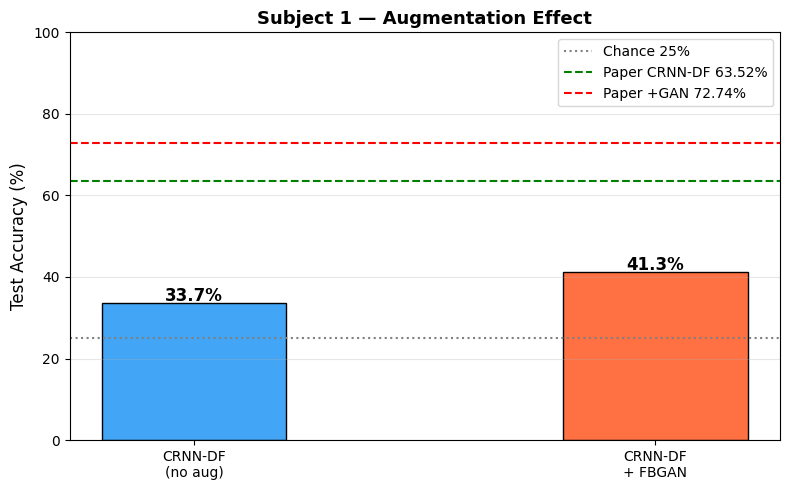

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['CRNN-DF\n(no aug)', 'CRNN-DF\n+ FBGAN']
vals   = [acc_noaug, acc_aug]
colors = ['#42A5F5', '#FF7043']
bars   = ax.bar(labels, vals, color=colors, edgecolor='k', width=0.4)
ax.axhline(25,    color='gray',  ls=':',  lw=1.5, label='Chance 25%')
ax.axhline(63.52, color='green', ls='--', lw=1.5, label='Paper CRNN-DF 63.52%')
ax.axhline(72.74, color='red',   ls='--', lw=1.5, label='Paper +GAN 72.74%')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, 100); ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title(f'Subject 1 — Augmentation Effect', fontweight='bold', fontsize=13)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('m5_augmentation_results.png', dpi=120, bbox_inches='tight')
plt.show()


In [9]:
print('=' * 50)
print(f'No augmentation  : {acc_noaug:.2f}%')
print(f'With FBGAN aug   : {acc_aug:.2f}%')
print(f'Paper CRNN-DF    : 63.52% (9-subj mean)')
print(f'Paper +GAN       : 72.74% (9-subj mean)')
print('=' * 50)

assert acc_noaug > 35, (
    f'FAIL: no-aug acc {acc_noaug:.1f}% — CRNN-DF not learning. Fix Module 4 first.')
assert acc_aug >= acc_noaug - 2, (
    f'FAIL: augmented ({acc_aug:.1f}%) much worse than no-aug ({acc_noaug:.1f}%). '
    f'GAN generating harmful data — try more GAN epochs or fewer fake samples.')

print('\n✅  MODULE 5 PASS')
print('→  Proceed to Module 6 (full 9-subject LOSO)')


No augmentation  : 33.68%
With FBGAN aug   : 41.32%
Paper CRNN-DF    : 63.52% (9-subj mean)
Paper +GAN       : 72.74% (9-subj mean)


AssertionError: FAIL: no-aug acc 33.7% — CRNN-DF not learning. Fix Module 4 first.